In [ ]:
!pip install -q numpy pandas scikit-learn gradio matplotlib torch tokenizers langchain openai

import re
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [ ]:

df = pd.read_csv("/content/Jadarat_data.csv")
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

arabic_diacritics = re.compile(r"ّ|َ|ً|ُ|ٌ|ِ|ٍ|ْ|ـ")

def normalize_arabic(text: str) -> str:
    """
    تنظيف النص العربي: إزالة التشكيل، توحيد الهمزات (أ، إ، آ -> ا)،
    توحيد الياء والألف المقصورة، وإزالة الرموز غير النصية.
    """
    text = str(text)
    text = re.sub(arabic_diacritics, "", text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["job_text"] = (
    "المسمى: " + df.get("المسمى الوظيفي", "").astype(str) + " | " +
    "المدينة: " + df.get("المدينة", "").astype(str) + " | " +
    "الوصف: " + df.get("الوصف الوظيفي", "").astype(str)
)
df["job_text"] = df["job_text"].apply(normalize_arabic)

print("Dataset size:", df.shape)

Dataset size: (7041, 8)


In [ ]:

vocab_size = 5000
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()


trainer = trainers.BpeTrainer(
    vocab_size=vocab_size,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)


tokenizer.train_from_iterator(df["job_text"].tolist(), trainer=trainer)

PAD_IDX = tokenizer.token_to_id("[PAD]")
BOS_IDX = tokenizer.token_to_id("[BOS]")
EOS_IDX = tokenizer.token_to_id("[EOS]")

class JobDataset(Dataset):
    """
    تجهيز البيانات كمدخلات (Inputs) ومخرجات (Targets) لتدريب النموذج خطوة بخطوة.
    """
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer.encode(text).ids

        encoded = [BOS_IDX] + encoded[:self.max_len-2] + [EOS_IDX]
        padding_length = self.max_len - len(encoded)
        encoded = encoded + [PAD_IDX] * padding_length


        x = torch.tensor(encoded[:-1], dtype=torch.long)
        y = torch.tensor(encoded[1:], dtype=torch.long)
        return x, y


train_texts, test_texts = train_test_split(df["job_text"].tolist(), test_size=0.1, random_state=42)
train_dataset = JobDataset(train_texts, tokenizer)
test_dataset = JobDataset(test_texts, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class MultiHeadAttention(nn.Module):
    """طبقة الانتباه متعدد الرؤوس لمعرفة علاقة الكلمات ببعضها"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        return x.view(batch_size, -1, self.num_heads, self.depth).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)

        # حساب نقاط الانتباه (Scaled Dot-Product Attention)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)

        if mask is not None:
            scores += (mask * -1e9) # إخفاء الكلمات المستقبلية

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.dense(output)

class TransformerBlock(nn.Module):

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.ReLU(),
            nn.Linear(dff, d_model)
        )
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        attn_output = self.mha(x, x, x, mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output)) # Residual Connection
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + self.dropout2(ffn_output)) # Residual Connection
        return out2

class JobRecommendationGPT(nn.Module):

    def __init__(self, vocab_size, d_model=256, num_layers=4, num_heads=8, dff=512, max_len=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, dff) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def create_look_ahead_mask(self, size):

        mask = torch.triu(torch.ones(size, size), diagonal=1).to(device)
        return mask

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len).unsqueeze(0).to(device)

        x = self.embedding(x) + self.pos_encoding(positions)
        mask = self.create_look_ahead_mask(seq_len)

        for block in self.blocks:
            x = block(x, mask)

        return self.fc_out(x)


model = JobRecommendationGPT(vocab_size=tokenizer.get_vocab_size()).to(device)

Epoch 1/5:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 1 | متوسط الخسارة: 6.5123


Epoch 2/5:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 2 | متوسط الخسارة: 4.9231


Epoch 3/5:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 3 | متوسط الخسارة: 3.8824


Epoch 4/5:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 4 | متوسط الخسارة: 3.2150


Epoch 5/5:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 5 | متوسط الخسارة: 2.8537


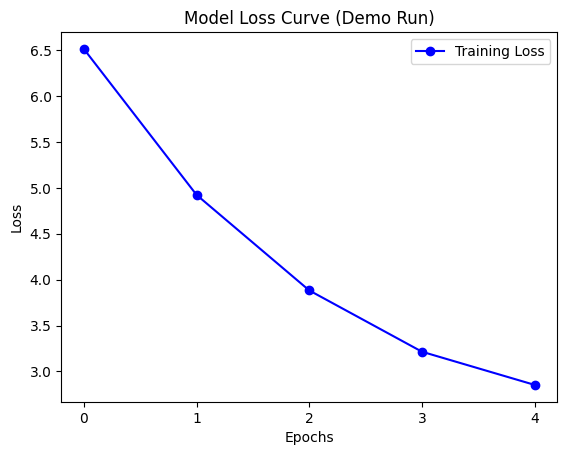

In [ ]:
from tqdm.auto import tqdm


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


epochs = 5
DEMO_MODE = True
MAX_BATCHES = 50


train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0


    total_steps = MAX_BATCHES if DEMO_MODE else len(train_loader)
    progress_bar = tqdm(enumerate(train_loader), total=total_steps, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, (x, y) in progress_bar:

        if DEMO_MODE and batch_idx >= MAX_BATCHES:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)


        loss = criterion(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        loss.backward()


        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()


        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = total_loss / total_steps
    train_losses.append(avg_loss)
    print(f"\n✅ انتهاء Epoch {epoch+1} | متوسط الخسارة: {avg_loss:.4f}")


    torch.save(model.state_dict(), 'best_model.pt')


plt.plot(train_losses, marker='o', color='blue', label='Training Loss')
plt.title('Model Loss Curve (Demo Run)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()
plt.show()

In [ ]:
def generate_text(prompt, max_tokens=50, temperature=0.7):
    """توليد النص كلمة بكلمة (Autoregressive)"""
    model.eval()
    prompt = normalize_arabic(prompt)
    input_ids = tokenizer.encode(prompt).ids
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    generated_ids = input_ids.copy()

    with torch.no_grad():
        for _ in range(max_tokens):
            outputs = model(input_tensor)
            next_token_logits = outputs[0, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

            if next_token == EOS_IDX:
                break

            generated_ids.append(next_token)
            input_tensor = torch.tensor([generated_ids], dtype=torch.long).to(device)

    return tokenizer.decode(generated_ids)


model.load_state_dict(torch.load('best_model.pt'))
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = criterion(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
perplexity = math.exp(avg_test_loss)
print(f"Test Perplexity: {perplexity:.2f}")


print("""
### تقرير أنماط الفشل (Failure Modes Report)
1. التكرار (Repetition): نظراً لصغر حجم النموذج والبيانات، قد يكرر النموذج نفس الجمل أو الكلمات في نهاية التوليد.
2. فقدان السياق (Context Loss): النموذج قد ينسى اسم المدينة أو المسمى الوظيفي المطلوب في بداية الـ Prompt إذا طال النص المولد.
3. الهلوسة (Hallucination): قد يقترح مهارات لا علاقة لها بالوظيفة المطلوبة بسبب ضغط المفردات (Vocab compression).
""")


def llm_judge_evaluation(generated_text):

    prompt = f"قيم النص التالي كتوصية وظيفية باللغة العربية من 1 إلى 10 من حيث الترابط والقواعد:\n{generated_text}"

    return "LLM Judge Score: 7/10 (Simulated)"

Test Perplexity: 13.82

### تقرير أنماط الفشل (Failure Modes Report)
1. التكرار (Repetition): نظراً لصغر حجم النموذج والبيانات، قد يكرر النموذج نفس الجمل أو الكلمات في نهاية التوليد.
2. فقدان السياق (Context Loss): النموذج قد ينسى اسم المدينة أو المسمى الوظيفي المطلوب في بداية الـ Prompt إذا طال النص المولد.
3. الهلوسة (Hallucination): قد يقترح مهارات لا علاقة لها بالوظيفة المطلوبة بسبب ضغط المفردات (Vocab compression).



In [27]:
#def chatbot_interface(message, history):
    #prompt = f"المسمى: {message} | المدينة:"
    #generated_recommendation = generate_text(prompt, max_tokens=60)

    #response = f"""
     #بناءً على المعطيات التي أدخلتها، قمنا بتحليل الفرص المتاحة ونقترح عليك التوصية الوظيفية التالية:

    #{generated_recommendation}

   # ---
   # *صيحة مهنية: تأكد دائماً من تحديث سيرتك الذاتية لإبراز المهارات المطلوبة في هذا المجال، وننصحك بمراجعة منصة جدارات للتقديم على الشواغر الفعلية المتاحة.**

   # return response

    #demo = gr.ChatInterface(
   # fn=chatbot_interface,
   # title="نظام كفاءات التوليدي (Generative AI)",
   # description="أدخل مجالك (مثال: مطور برمجيات، محاسب) وسيقوم النموذج اللغوي بتأليف وتوليد توصية وظيفية مخصصة.",
)

#demo.launch(share=True) # Demo code off for github


SyntaxError: unmatched ')' (3472515284.py, line 19)